In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

shrna_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv"
psp_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_PspCas13b_1nt.csv"
u1_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_RfxCas13d_U1-crRNA_1nt.csv"

shrna_df = pd.read_csv(shrna_in)
psp_df = pd.read_csv(psp_in)
u1_df = pd.read_csv(u1_in)

shrna_df["start_nt_NM_000371.3"] = pd.to_numeric(shrna_df["start_nt_NM_000371.3"], errors="coerce")
psp_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")
u1_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")

shrna_df = shrna_df[(shrna_df["start_nt_NM_000371.3"] >= 111) & (shrna_df["start_nt_NM_000371.3"] <= 709)].copy()
psp_df = psp_df[(psp_df["start_nt_NM_000371.3"] >= 111) & (psp_df["start_nt_NM_000371.3"] <= 697)].copy()
u1_df = u1_df[(u1_df["start_nt_NM_000371.3"] >= 111) & (u1_df["start_nt_NM_000371.3"] <= 704)].copy()

output_dir = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Figure5_Graph/Reviewed_Figure5/260724_Reviewed_Final"
os.makedirs(output_dir, exist_ok=True)

sigma_nt_default = 2
ttr_offset = 110
xticks_nt = [100, 200, 300, 400, 500, 600]
X_LABEL_TTR = "Guide RNA\nTTR transcript (NM_000371.4)"


In [2]:
def gaussian_smooth_by_nt(x, y, sigma_nt, truncate=4.0):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of the same length")
    dx = np.median(np.diff(x))
    if dx <= 0:
        raise ValueError("x must be strictly increasing")
    sigma_idx = sigma_nt / dx
    y_smooth = gaussian_filter1d(y, sigma=sigma_idx, mode="nearest", truncate=truncate)
    return x, y_smooth

In [3]:
# ---------- U1CasRx Day 1 ----------
d_day1 = u1_df[["start_nt_NM_000371.3", "rep3_day1_Log2FC"]].copy()
d_day1["start_nt_NM_000371.3"] = pd.to_numeric(d_day1["start_nt_NM_000371.3"], errors="coerce")
d_day1["rep3_day1_Log2FC"]     = pd.to_numeric(d_day1["rep3_day1_Log2FC"], errors="coerce")
d_day1 = d_day1.dropna(subset=["start_nt_NM_000371.3", "rep3_day1_Log2FC"]).sort_values("start_nt_NM_000371.3")
x_day1 = d_day1["start_nt_NM_000371.3"].to_numpy() - 110
y_day1 = d_day1["rep3_day1_Log2FC"].to_numpy()

# ---------- U1CasRx Day 5 ----------
d_day5 = u1_df[["start_nt_NM_000371.3", "rep3_day5_Log2FC"]].copy()
d_day5["start_nt_NM_000371.3"] = pd.to_numeric(d_day5["start_nt_NM_000371.3"], errors="coerce")
d_day5["rep3_day5_Log2FC"]     = pd.to_numeric(d_day5["rep3_day5_Log2FC"], errors="coerce")
d_day5 = d_day5.dropna(subset=["start_nt_NM_000371.3", "rep3_day5_Log2FC"]).sort_values("start_nt_NM_000371.3")
x_day5 = d_day5["start_nt_NM_000371.3"].to_numpy() - 110
y_day5 = d_day5["rep3_day5_Log2FC"].to_numpy()

# ---------- PSP Cas13b (single timepoint) ----------
d_psp = psp_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()  
d_psp["start_nt_NM_000371.3"] = pd.to_numeric(d_psp["start_nt_NM_000371.3"], errors="coerce")
d_psp["Log2FC_mean"] = pd.to_numeric(d_psp["Log2FC_mean"], errors="coerce")
d_psp = d_psp.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
x_psp = d_psp["start_nt_NM_000371.3"].to_numpy() - 110
y_psp = d_psp["Log2FC_mean"].to_numpy()

# ---------- shRNA (single timepoint or combined) ----------
# Likewise, adapt the Log2FC column name to your shRNA mastersheet
d_shrna = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()  # <-- replace "Log2FC" with actual shRNA column
d_shrna["start_nt_NM_000371.3"] = pd.to_numeric(d_shrna["start_nt_NM_000371.3"], errors="coerce")
d_shrna["Log2FC_mean"] = pd.to_numeric(d_shrna["Log2FC_mean"], errors="coerce")
d_shrna = d_shrna.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
x_shrna = d_shrna["start_nt_NM_000371.3"].to_numpy() - 110
y_shrna = d_shrna["Log2FC_mean"].to_numpy()

In [4]:
# ---------------------------------------------------------------------
# CDS region (in transcript coordinates, then shifted)
# ---------------------------------------------------------------------
cds_start_orig = 137
cds_end_orig   = 580

# Adjust for your offset (x = start_nt - ttr_offset)
cds_x0 = cds_start_orig - ttr_offset
cds_x1 = cds_end_orig   - ttr_offset

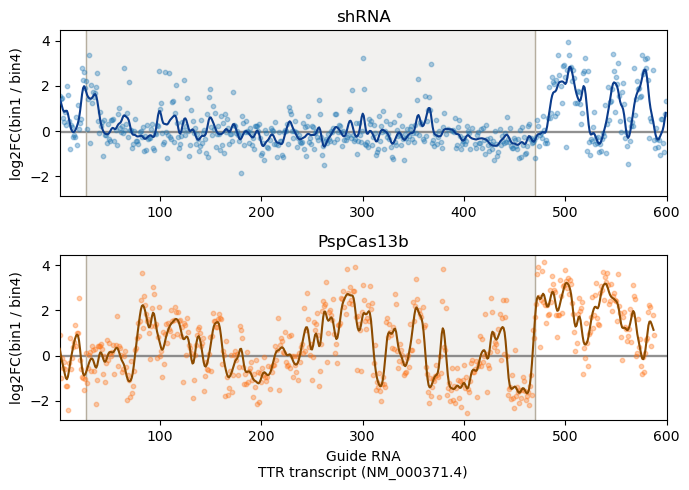

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharey=True)
plotspecs = [
    (shrna_df, "shRNA", "tab:blue", "#0b3c8c"),
    (psp_df, "PspCas13b", "#FF7418A4", "#8c4b00"),
]

for ax, (data, title, dot_c, line_c) in zip(axes, plotspecs):
    d = data[["start_nt_NM_000371.3", "Log2FC_mean"]].apply(pd.to_numeric, errors="coerce").dropna()
    d = d.sort_values("start_nt_NM_000371.3")
    x = d["start_nt_NM_000371.3"].to_numpy() - ttr_offset
    y = d["Log2FC_mean"].to_numpy()

    # CDS band and boundary lines
    ax.axvspan(cds_x0, cds_x1, color="#E0DED7", alpha=0.4, zorder=0)
    ax.axvline(cds_x0, color="#B6AE9F", linewidth=1, zorder=1)
    ax.axvline(cds_x1, color="#B6AE9F", linewidth=1, zorder=1)

    # Horizontal band around log2FC ~ 0
    ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)

    # Scatter
    ax.scatter(x, y, s=10, color=dot_c, alpha=0.35, zorder=2)

    xs, ys = gaussian_smooth_by_nt(x, y, sigma_nt_default)
    ax.plot(xs, ys, color=line_c, lw=1.5, zorder=3)

    ax.margins(x=0)
    ax.set_title(title)
    ax.set_ylabel("log2FC(bin1 / bin4)")
    ax.set_xticks(xticks_nt)

axes[-1].set_xlabel(X_LABEL_TTR)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "260724_MainFigure5_Graph_Gaussian_shRNA_PspCas13b.pdf"), bbox_inches="tight")
plt.show()

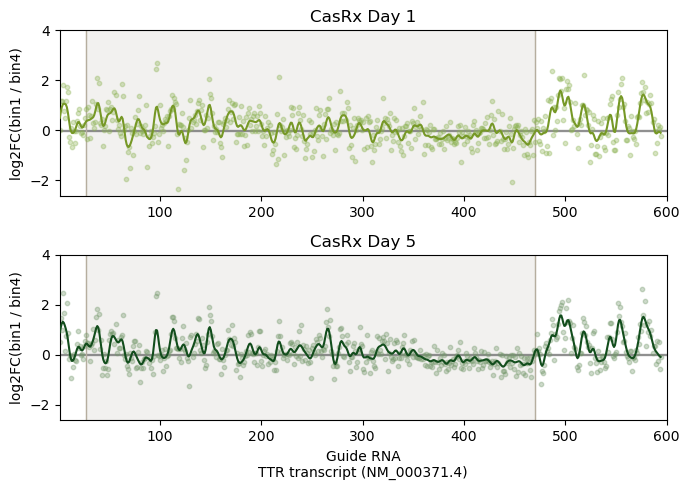

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharey=True)

plotspecs = [
    (d_day1, "CasRx Day 1", "rep3_day1_Log2FC", "#8DB355", "#769826"),
    (d_day5, "CasRx Day 5", "rep3_day5_Log2FC", "#73976A", "#124D1C"),
]

for ax, (data, title, y_col, dot_c, line_c) in zip(axes, plotspecs):
    d = data[["start_nt_NM_000371.3", y_col]].apply(pd.to_numeric, errors="coerce").dropna()
    d = d.sort_values("start_nt_NM_000371.3")
    x = d["start_nt_NM_000371.3"].to_numpy() - ttr_offset
    y = d[y_col].to_numpy()

    # CDS band and boundary lines
    ax.axvspan(cds_x0, cds_x1, color="#E0DED7", alpha=0.4, zorder=0)
    ax.axvline(cds_x0, color="#B6AE9F", linewidth=1, zorder=1)
    ax.axvline(cds_x1, color="#B6AE9F", linewidth=1, zorder=1)

    # Horizontal band around log2FC ~ 0
    ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)

    # Scatter
    ax.scatter(x, y, s=10, color=dot_c, alpha=0.35, zorder=2)

    # Gaussian smoothing in nt space
    xs, ys = gaussian_smooth_by_nt(x, y, sigma_nt_default)
    ax.plot(xs, ys, color=line_c, lw=1.5, zorder=3)

    ax.margins(x=0)
    ax.set_title(title)
    ax.set_ylabel("log2FC(bin1 / bin4)")
    ax.set_xticks(xticks_nt)
    ax.set_yticks([-2, 0, 2, 4])

axes[-1].set_xlabel(X_LABEL_TTR)

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "260724_MainFigure5_Graph_Gaussian_CasRx_Day1_Day5.pdf"), bbox_inches="tight")
plt.show()